# Seizure Classification Study Visualizations

This notebook provides visualizations for the systematic literature review of epileptic seizure detection and prediction studies.

In [7]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Set style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Load the seizure classification data
df = pd.read_csv('/home/paulin/Documents/Epilepsie/Results/seizure_classification_2.csv')
print(f"Total studies: {len(df)}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Total studies: 9

Columns: ['CitationKey', 'Setting', 'Modality', 'Task', 'ModelClass', 'StudyPhase', 'EvalGranularity', 'Windowing', 'Personalization', 'InferenceHardware']


,CitationKey,Setting,Modality,Task,ModelClass,StudyPhase,EvalGranularity,Windowing,Personalization,InferenceHardware
0,dongTwoLayerEnsemble2022,Ambulatory,ACC/GYR,Detection,TLEM(Stacking),Retrospective,Alarm,2s/1sOverlap,Mark Button,Wearable-CPU
1,elemamAutomatedValidated2025,Clinical/Ambu,Audio/HRV,Detection/Prediction,CNN,Prospective,Alarm,10s,Patient-rating,Android/JS
2,fineDetectionKeyAutomated2025,Clinical,ACC/GYR,Detection,ANN,Prospective,Alarm,10s/1sOverlap,NaN,PC-Offline
3,meiselMachineLearningWristband2020,Clinical,Multimodal-Wrist,Prediction,LSTM/1DConv,Pseudo-Pros,Alarm,30s,Transfer-learning,DeepLearning-PC
4,odeDevelopmentEpileptic2023,Clinical,ECG(RRI),Prediction,SA-AE,Retrospective,Alarm,45s,Individual-Limits,Python-Optuna


## 1. Study Settings Distribution
Distribution of studies across clinical, ambulatory, and combined settings.

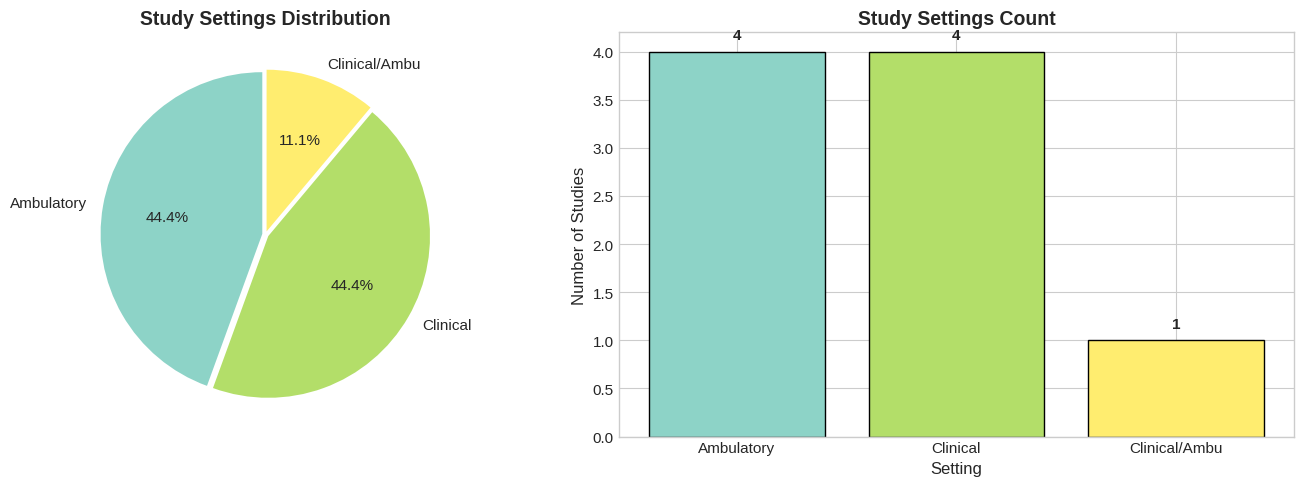

In [8]:
# Study Setting Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
setting_counts = df['Setting'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(setting_counts)))
axes[0].pie(setting_counts.values, labels=setting_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90, explode=[0.02]*len(setting_counts))
axes[0].set_title('Study Settings Distribution', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[1].bar(setting_counts.index, setting_counts.values, color=colors, edgecolor='black')
axes[1].set_xlabel('Setting', fontsize=12)
axes[1].set_ylabel('Number of Studies', fontsize=12)
axes[1].set_title('Study Settings Count', fontsize=14, fontweight='bold')
for bar, count in zip(bars, setting_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                 str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Task Type Distribution
Comparison of studies focusing on Detection, Prediction, or both.

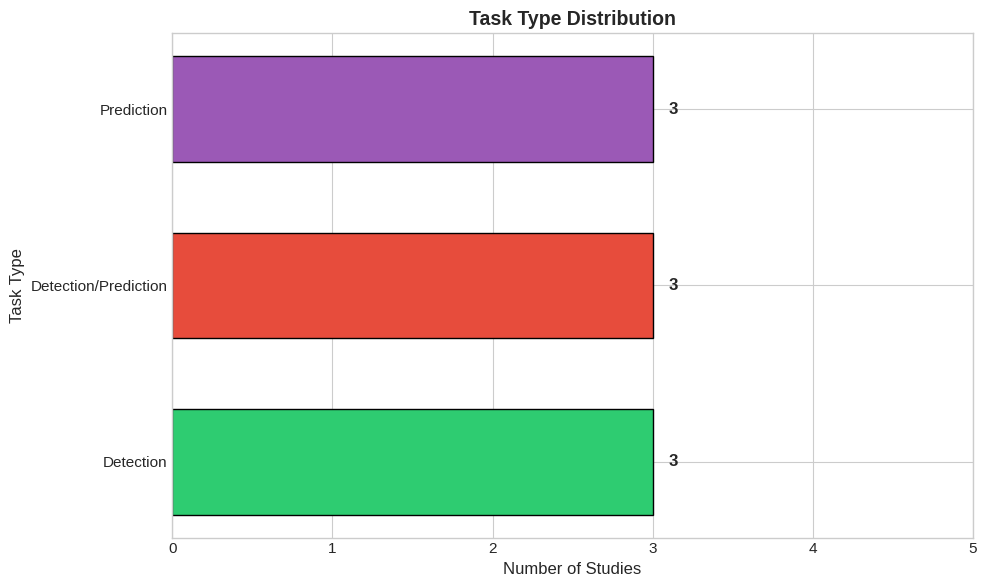

In [9]:
# Task Distribution
fig, ax = plt.subplots(figsize=(10, 6))

task_counts = df['Task'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#9b59b6'][:len(task_counts)]
bars = ax.barh(task_counts.index, task_counts.values, color=colors, edgecolor='black', height=0.6)

ax.set_xlabel('Number of Studies', fontsize=12)
ax.set_ylabel('Task Type', fontsize=12)
ax.set_title('Task Type Distribution', fontsize=14, fontweight='bold')

for bar, count in zip(bars, task_counts.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
            str(count), ha='left', va='center', fontweight='bold', fontsize=12)

ax.set_xlim(0, max(task_counts.values) + 2)
plt.tight_layout()
plt.show()

## 3. Study Phase Distribution
Distribution of retrospective, prospective, and pseudo-prospective studies.

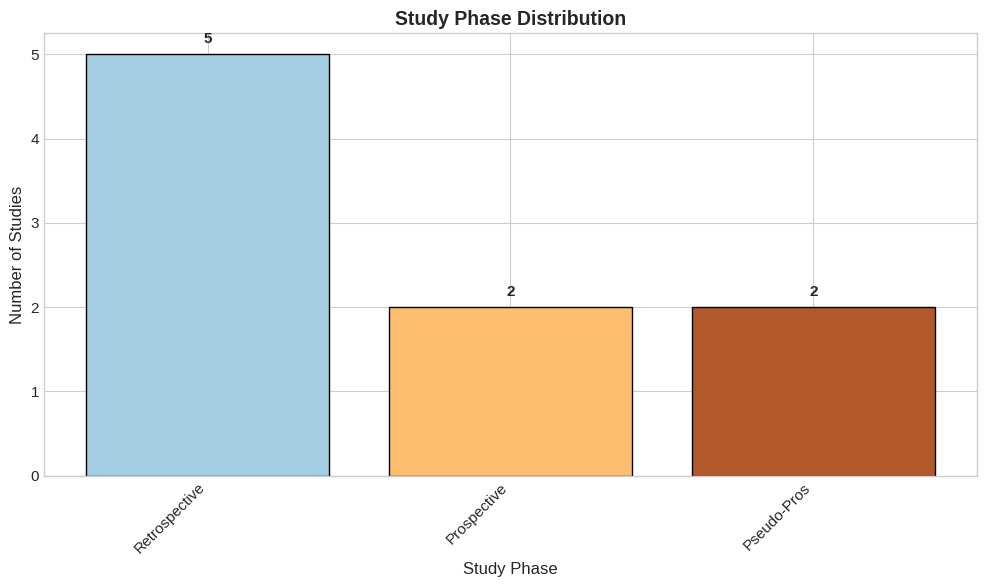

In [10]:
# Study Phase Distribution
fig, ax = plt.subplots(figsize=(10, 6))

phase_counts = df['StudyPhase'].value_counts()
colors = plt.cm.Paired(np.linspace(0, 1, len(phase_counts)))
bars = ax.bar(range(len(phase_counts)), phase_counts.values, color=colors, edgecolor='black')

ax.set_xticks(range(len(phase_counts)))
ax.set_xticklabels(phase_counts.index, rotation=45, ha='right')
ax.set_xlabel('Study Phase', fontsize=12)
ax.set_ylabel('Number of Studies', fontsize=12)
ax.set_title('Study Phase Distribution', fontsize=14, fontweight='bold')

for bar, count in zip(bars, phase_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
            str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Sensor Modalities Analysis
Analysis of different sensor modalities used across studies (ACC, ECG, EEG, sEMG, etc.).

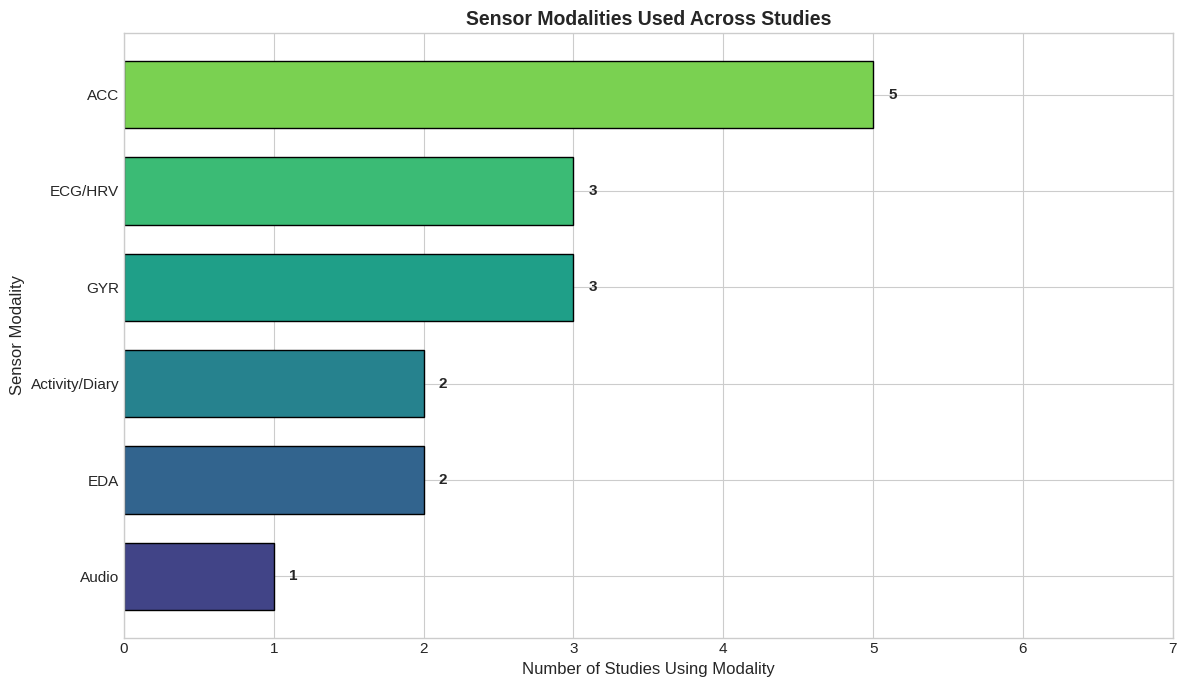


Modality counts:
      Modality  Count
           ACC      5
           GYR      3
       ECG/HRV      3
           EDA      2
Activity/Diary      2
         Audio      1


In [11]:
# Sensor Modality Analysis - Extract individual modalities
def extract_modalities(modality_str):
    """Extract individual sensor types from modality string"""
    # Split by / and clean up
    parts = modality_str.replace('(', '/').replace(')', '').split('/')
    modalities = []
    for p in parts:
        p = p.strip()
        if p and len(p) > 0:
            # Normalize common variants
            if p.upper() in ['ACC', 'GYRO', 'GYR']:
                modalities.append(p.upper())
            elif 'ECG' in p.upper() or 'RRI' in p.upper() or 'HRV' in p.upper() or 'EDR' in p.upper() or 'HR' == p.upper():
                modalities.append('ECG/HRV')
            elif 'EEG' in p.upper() or 'SEEG' in p.upper():
                modalities.append('EEG/sEEG')
            elif 'EMG' in p.upper():
                modalities.append('sEMG')
            elif 'EDA' in p.upper():
                modalities.append('EDA')
            elif 'PPG' in p.upper() or 'BVP' in p.upper():
                modalities.append('PPG/BVP')
            elif 'TEMP' in p.upper():
                modalities.append('TEMP')
            elif 'AUDIO' in p.upper():
                modalities.append('Audio')
            elif 'RESP' in p.upper():
                modalities.append('Resp')
            elif 'SLEEP' in p.upper() or 'STEPS' in p.upper() or 'DIARY' in p.upper():
                modalities.append('Activity/Diary')
    return list(set(modalities))

# Count modalities
all_modalities = []
for mod in df['Modality']:
    all_modalities.extend(extract_modalities(mod))

modality_counts = Counter(all_modalities)
modality_df = pd.DataFrame(modality_counts.items(), columns=['Modality', 'Count']).sort_values('Count', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(modality_df)))
bars = ax.barh(modality_df['Modality'], modality_df['Count'], color=colors, edgecolor='black', height=0.7)

ax.set_xlabel('Number of Studies Using Modality', fontsize=12)
ax.set_ylabel('Sensor Modality', fontsize=12)
ax.set_title('Sensor Modalities Used Across Studies', fontsize=14, fontweight='bold')

for bar, count in zip(bars, modality_df['Count']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
            str(count), ha='left', va='center', fontweight='bold', fontsize=11)

ax.set_xlim(0, max(modality_df['Count']) + 2)
plt.tight_layout()
plt.show()

print(f"\nModality counts:\n{modality_df.sort_values('Count', ascending=False).to_string(index=False)}")

## 5. Model Classes / Algorithm Types
Overview of machine learning approaches used (Deep Learning, Ensemble Methods, Traditional ML, etc.).

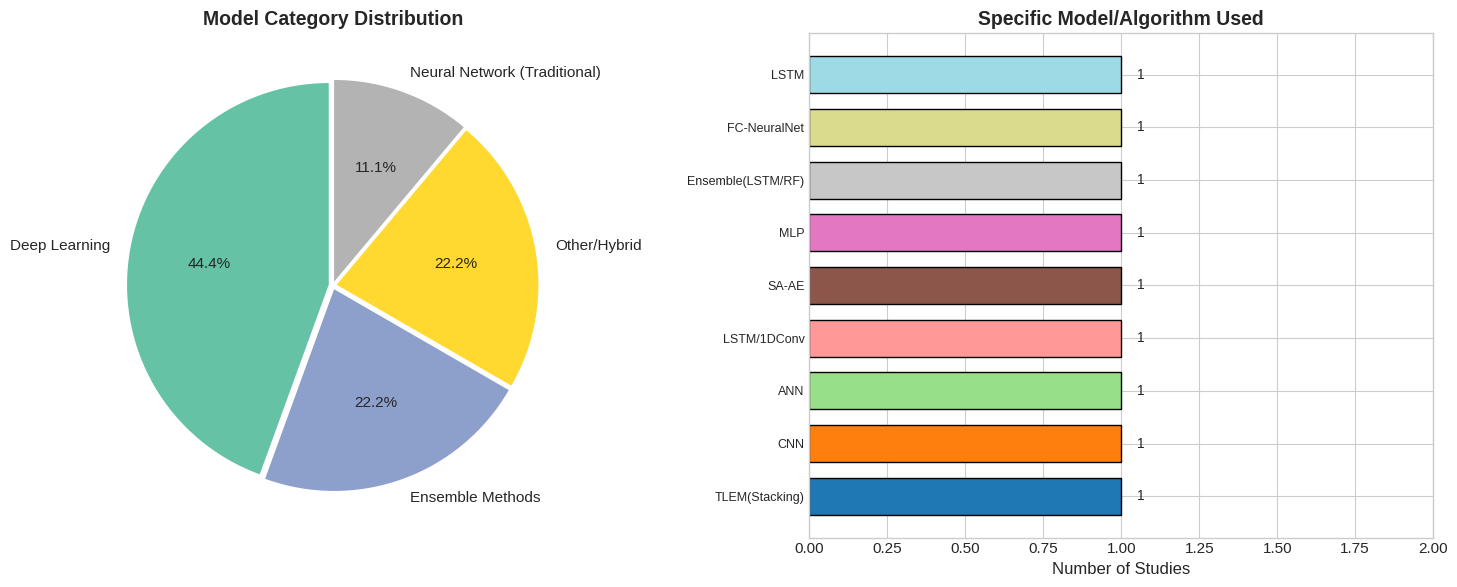

In [12]:
# Model Class Categorization
def categorize_model(model_str):
    """Categorize models into broader classes"""
    model_upper = model_str.upper()
    if any(x in model_upper for x in ['CNN', 'LSTM', 'ATTENTION', 'FCN', 'RESNET', 'DEEP']):
        return 'Deep Learning'
    elif any(x in model_upper for x in ['RF', 'RANDOM FOREST', 'ENSEMBLE', 'TLEM', 'XGBOOST', 'GBDT', 'ADABOOST', 'ET']):
        return 'Ensemble Methods'
    elif any(x in model_upper for x in ['SVM', 'SUPERVISED']):
        return 'SVM'
    elif any(x in model_upper for x in ['ANN', 'NEURAL']):
        return 'Neural Network (Traditional)'
    elif any(x in model_upper for x in ['THRESHOLD', 'RULE']):
        return 'Rule-based/Threshold'
    elif any(x in model_upper for x in ['REGRESSION', 'PCA', 'MSPC']):
        return 'Statistical Methods'
    else:
        return 'Other/Hybrid'

df['ModelCategory'] = df['ModelClass'].apply(categorize_model)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart for categories
cat_counts = df['ModelCategory'].value_counts()
colors = plt.cm.Set2(np.linspace(0, 1, len(cat_counts)))
wedges, texts, autotexts = axes[0].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%', 
                                        colors=colors, startangle=90, explode=[0.02]*len(cat_counts))
axes[0].set_title('Model Category Distribution', fontsize=14, fontweight='bold')

# Detailed model bar chart
model_counts = df['ModelClass'].value_counts()
y_pos = range(len(model_counts))
colors_bar = plt.cm.tab20(np.linspace(0, 1, len(model_counts)))
bars = axes[1].barh(y_pos, model_counts.values, color=colors_bar, edgecolor='black', height=0.7)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(model_counts.index, fontsize=9)
axes[1].set_xlabel('Number of Studies', fontsize=12)
axes[1].set_title('Specific Model/Algorithm Used', fontsize=14, fontweight='bold')

for bar, count in zip(bars, model_counts.values):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, 
                 str(count), ha='left', va='center', fontsize=10)

axes[1].set_xlim(0, max(model_counts.values) + 1)
plt.tight_layout()
plt.show()

## 6. Evaluation Granularity
How studies evaluate their models: alarm-based, sample-based, metric-based, or day-based approaches.

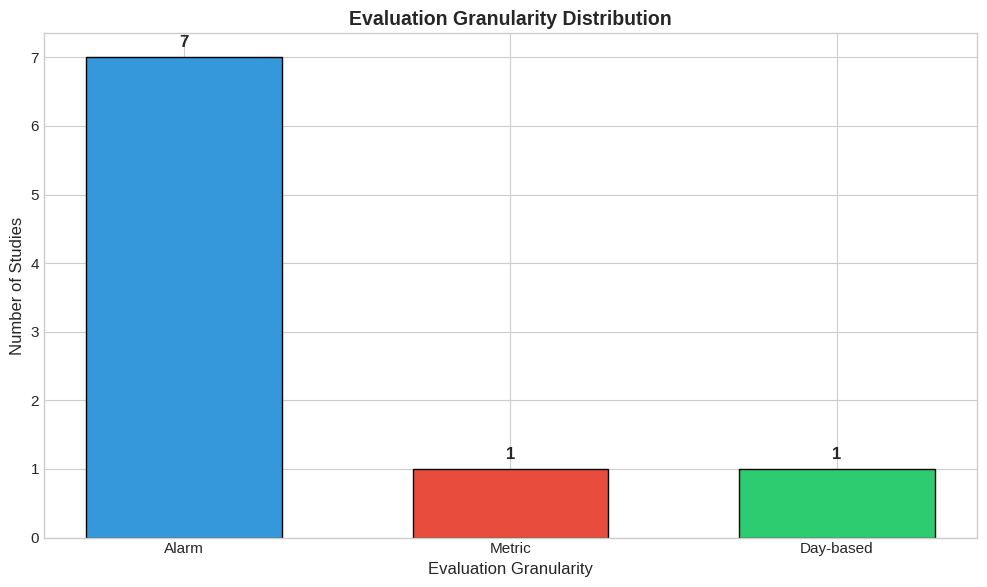

In [13]:
# Evaluation Granularity Distribution
fig, ax = plt.subplots(figsize=(10, 6))

eval_counts = df['EvalGranularity'].value_counts()
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12'][:len(eval_counts)]
bars = ax.bar(eval_counts.index, eval_counts.values, color=colors, edgecolor='black', width=0.6)

ax.set_xlabel('Evaluation Granularity', fontsize=12)
ax.set_ylabel('Number of Studies', fontsize=12)
ax.set_title('Evaluation Granularity Distribution', fontsize=14, fontweight='bold')

for bar, count in zip(bars, eval_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

## 7. Inference Hardware / Deployment Target
Where the models are deployed: wearables, smartphones, cloud, embedded systems, or offline analysis.

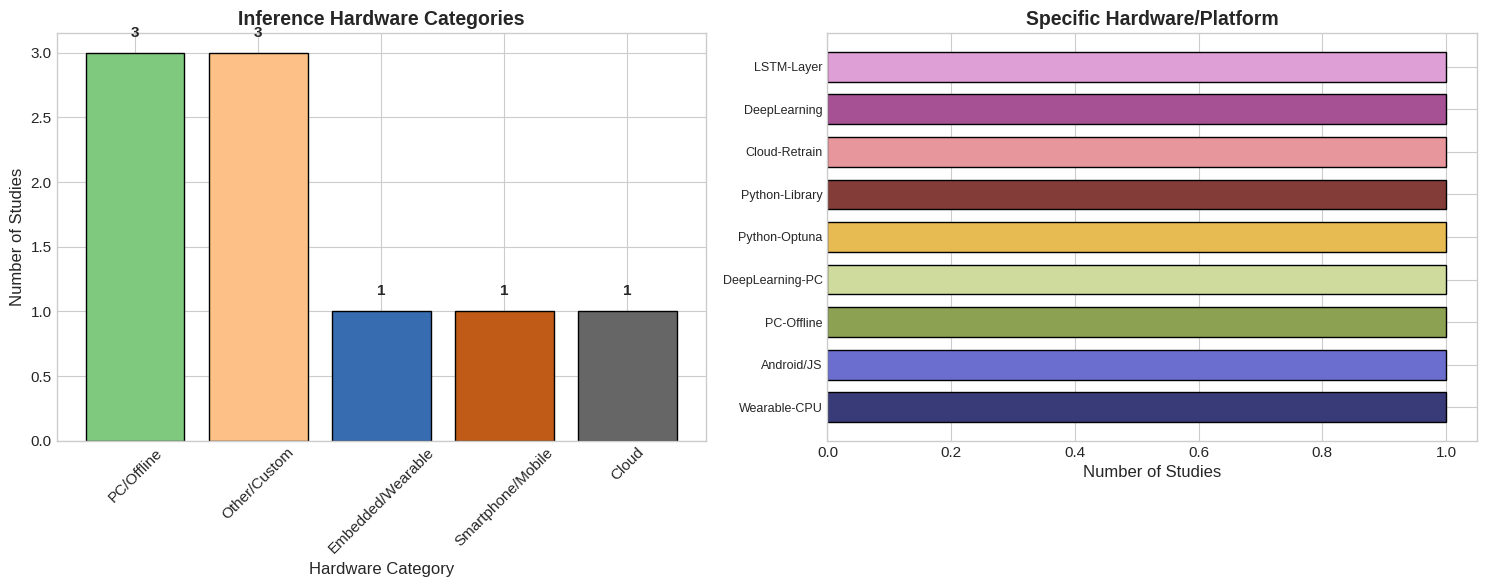

In [14]:
# Inference Hardware Categorization
def categorize_hardware(hw_str):
    """Categorize hardware into broader classes"""
    hw_upper = hw_str.upper()
    if any(x in hw_upper for x in ['WEARABLE', 'CORTEX', 'EMBEDDED', 'CHIP', 'M3']):
        return 'Embedded/Wearable'
    elif any(x in hw_upper for x in ['SMARTPHONE', 'ANDROID', 'MOBILE']):
        return 'Smartphone/Mobile'
    elif any(x in hw_upper for x in ['CLOUD', 'RETRAINING']):
        return 'Cloud'
    elif any(x in hw_upper for x in ['PC', 'OFFLINE', 'DEEP']):
        return 'PC/Offline'
    elif any(x in hw_upper for x in ['REAL-TIME', 'WIFI', 'STATION']):
        return 'Real-time System'
    elif any(x in hw_upper for x in ['HOSPITAL', 'HEXOSKIN', 'BIOVITAL', 'WRISTBAND']):
        return 'Medical Device'
    else:
        return 'Other/Custom'

df['HardwareCategory'] = df['InferenceHardware'].apply(categorize_hardware)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Category distribution
hw_cat_counts = df['HardwareCategory'].value_counts()
colors = plt.cm.Accent(np.linspace(0, 1, len(hw_cat_counts)))
bars = axes[0].bar(hw_cat_counts.index, hw_cat_counts.values, color=colors, edgecolor='black')
axes[0].set_xlabel('Hardware Category', fontsize=12)
axes[0].set_ylabel('Number of Studies', fontsize=12)
axes[0].set_title('Inference Hardware Categories', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
for bar, count in zip(bars, hw_cat_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                 str(count), ha='center', va='bottom', fontweight='bold')

# Detailed hardware
hw_counts = df['InferenceHardware'].value_counts()
y_pos = range(len(hw_counts))
colors_bar = plt.cm.tab20b(np.linspace(0, 1, len(hw_counts)))
bars = axes[1].barh(y_pos, hw_counts.values, color=colors_bar, edgecolor='black', height=0.7)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(hw_counts.index, fontsize=9)
axes[1].set_xlabel('Number of Studies', fontsize=12)
axes[1].set_title('Specific Hardware/Platform', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Personalization Strategies
How studies handle patient-specific adaptations: transfer learning, individual calibration, cross-validation approaches, etc.

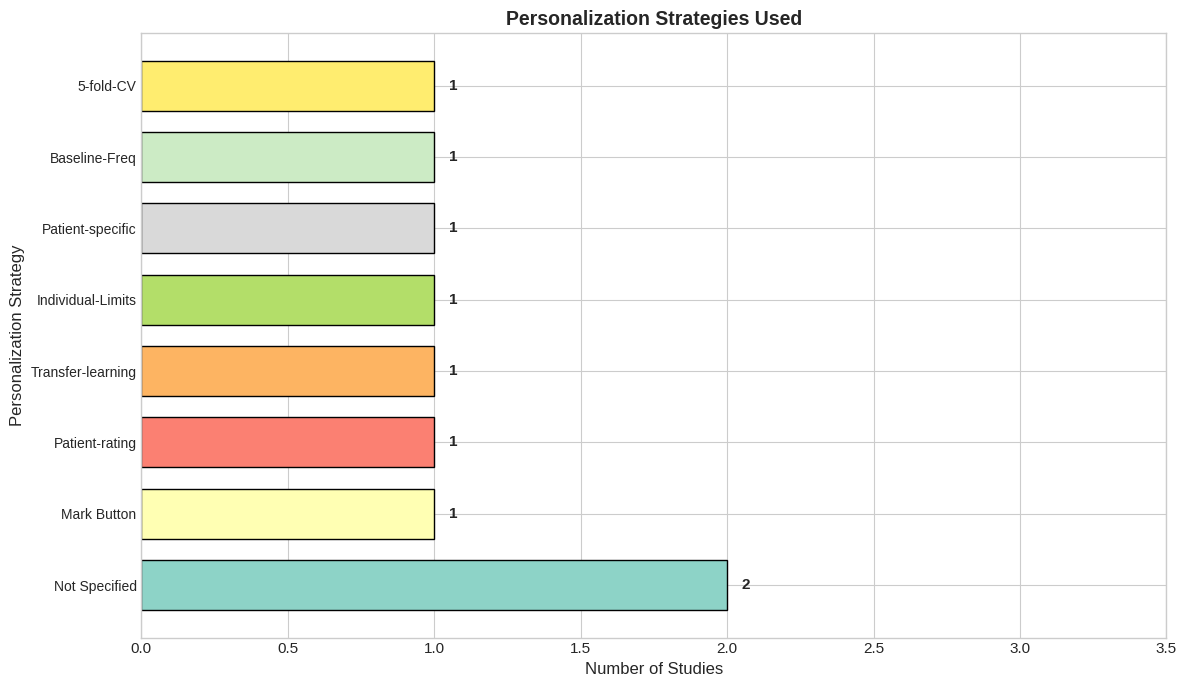

In [15]:
# Personalization Strategy Distribution
fig, ax = plt.subplots(figsize=(12, 7))

# Handle NaN values
personal_counts = df['Personalization'].fillna('Not Specified').value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(personal_counts)))
y_pos = range(len(personal_counts))

bars = ax.barh(y_pos, personal_counts.values, color=colors, edgecolor='black', height=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(personal_counts.index, fontsize=10)
ax.set_xlabel('Number of Studies', fontsize=12)
ax.set_ylabel('Personalization Strategy', fontsize=12)
ax.set_title('Personalization Strategies Used', fontsize=14, fontweight='bold')

for bar, count in zip(bars, personal_counts.values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, 
            str(count), ha='left', va='center', fontweight='bold', fontsize=11)

ax.set_xlim(0, max(personal_counts.values) + 1.5)
plt.tight_layout()
plt.show()

## 9. Cross-Tabulation Analysis
Heatmaps showing relationships between different study characteristics.

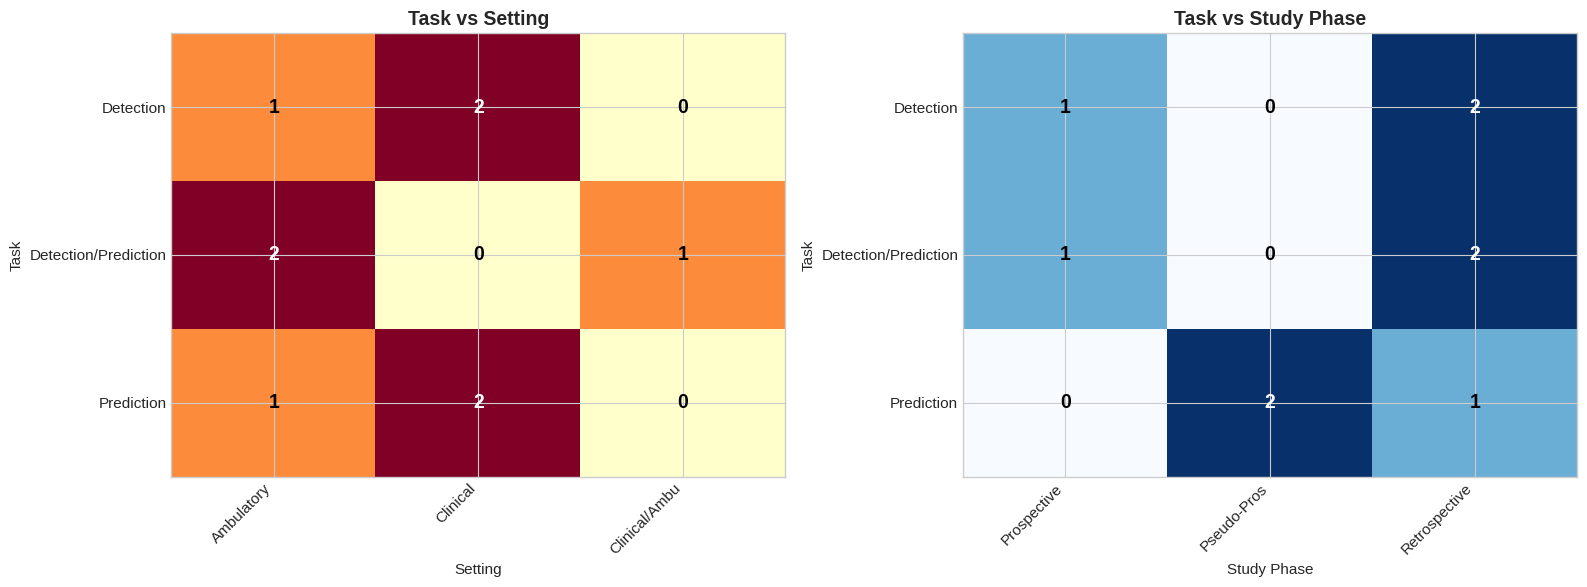

In [16]:
# Cross-Tabulation Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Task vs Setting
cross_tab1 = pd.crosstab(df['Task'], df['Setting'])
im1 = axes[0].imshow(cross_tab1.values, cmap='YlOrRd', aspect='auto')
axes[0].set_xticks(range(len(cross_tab1.columns)))
axes[0].set_xticklabels(cross_tab1.columns, rotation=45, ha='right')
axes[0].set_yticks(range(len(cross_tab1.index)))
axes[0].set_yticklabels(cross_tab1.index)
axes[0].set_title('Task vs Setting', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Setting')
axes[0].set_ylabel('Task')

# Add text annotations
for i in range(len(cross_tab1.index)):
    for j in range(len(cross_tab1.columns)):
        text = axes[0].text(j, i, cross_tab1.values[i, j], ha='center', va='center', 
                           color='white' if cross_tab1.values[i, j] > cross_tab1.values.max()/2 else 'black',
                           fontweight='bold', fontsize=14)

# Task vs Study Phase
cross_tab2 = pd.crosstab(df['Task'], df['StudyPhase'])
im2 = axes[1].imshow(cross_tab2.values, cmap='Blues', aspect='auto')
axes[1].set_xticks(range(len(cross_tab2.columns)))
axes[1].set_xticklabels(cross_tab2.columns, rotation=45, ha='right')
axes[1].set_yticks(range(len(cross_tab2.index)))
axes[1].set_yticklabels(cross_tab2.index)
axes[1].set_title('Task vs Study Phase', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Study Phase')
axes[1].set_ylabel('Task')

for i in range(len(cross_tab2.index)):
    for j in range(len(cross_tab2.columns)):
        text = axes[1].text(j, i, cross_tab2.values[i, j], ha='center', va='center',
                           color='white' if cross_tab2.values[i, j] > cross_tab2.values.max()/2 else 'black',
                           fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

## 10. Summary Dashboard
Comprehensive overview of all study characteristics in a single view.

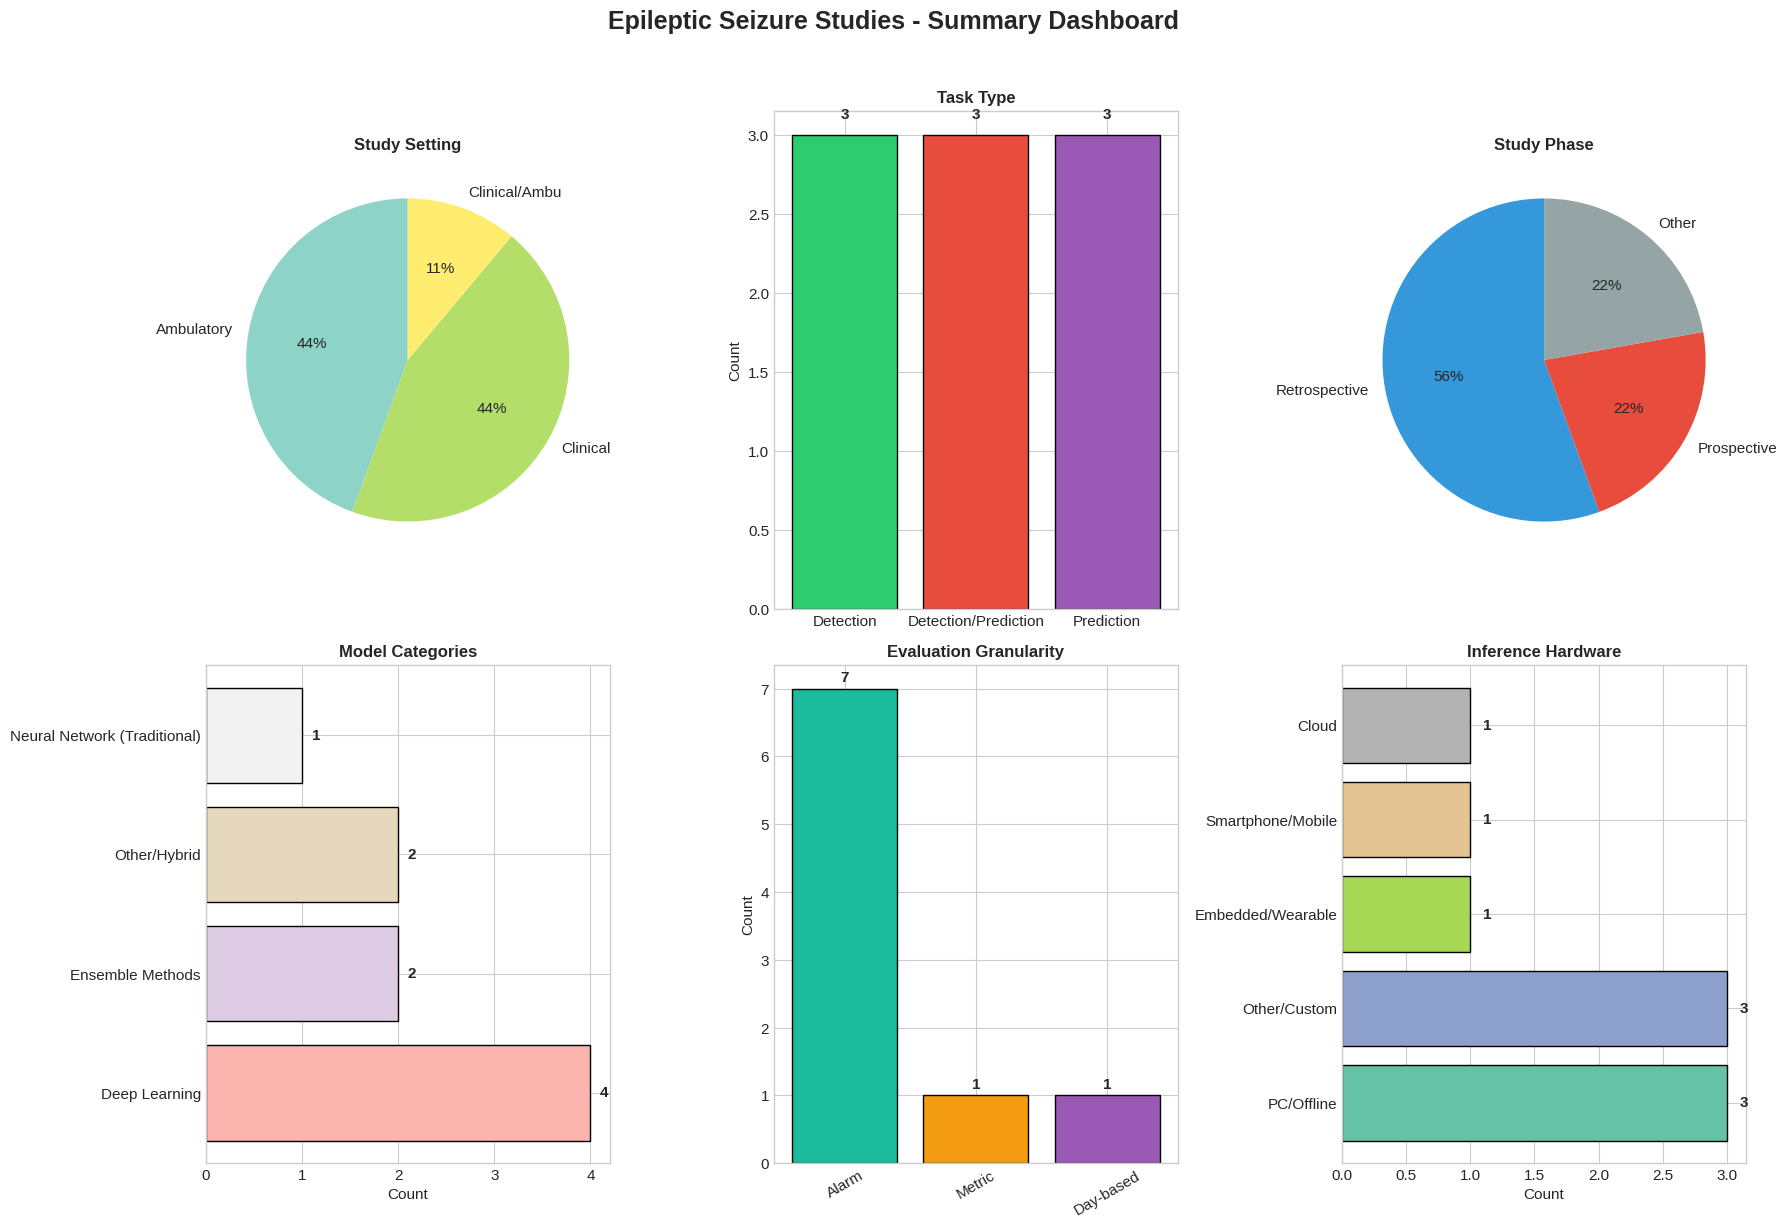


SUMMARY STATISTICS
Total Studies: 9

Task Distribution:
  - Detection: 3 (33.3%)
  - Detection/Prediction: 3 (33.3%)
  - Prediction: 3 (33.3%)

Most Common Setting: Ambulatory
Most Common Model Category: Deep Learning
Most Common Evaluation: Alarm


In [17]:
# Summary Dashboard - All Key Metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Epileptic Seizure Studies - Summary Dashboard', fontsize=18, fontweight='bold', y=1.02)

# 1. Setting
setting_counts = df['Setting'].value_counts()
axes[0, 0].pie(setting_counts.values, labels=setting_counts.index, autopct='%1.0f%%', 
               colors=plt.cm.Set3(np.linspace(0, 1, len(setting_counts))), startangle=90)
axes[0, 0].set_title('Study Setting', fontsize=12, fontweight='bold')

# 2. Task
task_counts = df['Task'].value_counts()
bars = axes[0, 1].bar(task_counts.index, task_counts.values, color=['#2ecc71', '#e74c3c', '#9b59b6'][:len(task_counts)], edgecolor='black')
axes[0, 1].set_title('Task Type', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Count')
for bar, count in zip(bars, task_counts.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(count), ha='center', fontweight='bold')

# 3. Study Phase (simplified)
phase_simple = df['StudyPhase'].apply(lambda x: 'Prospective' if 'Prospective' in x else ('Retrospective' if 'Retrospective' in x else 'Other'))
phase_counts = phase_simple.value_counts()
axes[0, 2].pie(phase_counts.values, labels=phase_counts.index, autopct='%1.0f%%',
               colors=['#3498db', '#e74c3c', '#95a5a6'], startangle=90)
axes[0, 2].set_title('Study Phase', fontsize=12, fontweight='bold')

# 4. Model Categories
cat_counts = df['ModelCategory'].value_counts()
bars = axes[1, 0].barh(cat_counts.index, cat_counts.values, color=plt.cm.Pastel1(np.linspace(0, 1, len(cat_counts))), edgecolor='black')
axes[1, 0].set_title('Model Categories', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Count')
for bar, count in zip(bars, cat_counts.values):
    axes[1, 0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, str(count), va='center', fontweight='bold')

# 5. Evaluation Granularity
eval_counts = df['EvalGranularity'].value_counts()
bars = axes[1, 1].bar(eval_counts.index, eval_counts.values, color=['#1abc9c', '#f39c12', '#9b59b6', '#34495e'][:len(eval_counts)], edgecolor='black')
axes[1, 1].set_title('Evaluation Granularity', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=30)
for bar, count in zip(bars, eval_counts.values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(count), ha='center', fontweight='bold')

# 6. Hardware Categories
hw_counts = df['HardwareCategory'].value_counts()
bars = axes[1, 2].barh(hw_counts.index, hw_counts.values, color=plt.cm.Set2(np.linspace(0, 1, len(hw_counts))), edgecolor='black')
axes[1, 2].set_title('Inference Hardware', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Count')
for bar, count in zip(bars, hw_counts.values):
    axes[1, 2].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, str(count), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n{'='*60}")
print(f"SUMMARY STATISTICS")
print(f"{'='*60}")
print(f"Total Studies: {len(df)}")
print(f"\nTask Distribution:")
for task, count in df['Task'].value_counts().items():
    print(f"  - {task}: {count} ({count/len(df)*100:.1f}%)")
print(f"\nMost Common Setting: {df['Setting'].mode()[0]}")
print(f"Most Common Model Category: {df['ModelCategory'].mode()[0]}")
print(f"Most Common Evaluation: {df['EvalGranularity'].mode()[0]}")